<a href="https://colab.research.google.com/github/aidev-ahmedamr/real-time-dynamic-pricing-engine/blob/main/notebooks/05_dynamic_pricing_engine.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
from google.colab import files

uploaded = files.upload()

Saving dynamic_pricing_processed.csv to dynamic_pricing_processed.csv


In [2]:
from google.colab import files

uploaded = files.upload()

Saving demand_model.pkl to demand_model.pkl


In [3]:
from google.colab import files

uploaded = files.upload()

Saving model_features.pkl to model_features.pkl


In [4]:
import joblib
import pandas as pd
import numpy as np

model = joblib.load(
    "demand_model.pkl"
)

features = joblib.load(
    "model_features.pkl"
)

In [8]:
def optimize_price(
    product_data,
    model,
    features,
    min_margin=0.10,
    max_price_increase=0.20,
    max_price_decrease=0.20,
    num_candidates=21
):

    current_price = product_data["current_price"]

    cost_price = product_data["cost_price"]

    min_price = max(
        cost_price * (1 + min_margin),
        current_price * (1 - max_price_decrease)
    )

    max_price = current_price * (
        1 + max_price_increase
    )

    candidate_prices = np.linspace(
        min_price,
        max_price,
        num_candidates
    )

    results = []

    for candidate_price in candidate_prices:

        temp = product_data.copy()

        temp["current_price"] = candidate_price

        temp["price_ratio_to_competitor"] = (
            candidate_price
            / temp["competitor_price"]
        )

        temp["price_difference"] = (
            candidate_price
            - temp["competitor_price"]
        )

        temp["profit_margin"] = (
            (candidate_price - temp["cost_price"])
            / candidate_price
        )

        input_df = pd.DataFrame(
            [temp]
        )[features]

        predicted_demand = max(
            0,
            model.predict(input_df)[0]
        )

        expected_revenue = (
            candidate_price
            * predicted_demand
        )

        expected_profit = (
            (candidate_price - cost_price)
            * predicted_demand
        )

        results.append({
            "candidate_price": round(
                candidate_price,
                2
            ),
            "predicted_demand": round(
                predicted_demand,
                2
            ),
            "expected_revenue": round(
                expected_revenue,
                2
            ),
            "expected_profit": round(
                expected_profit,
                2
            )
        })

    results_df = pd.DataFrame(
        results
    )

    best_result = results_df.loc[
        results_df[
            "expected_profit"
        ].idxmax()
    ]

    return best_result, results_df

In [11]:
import pandas as pd

df = pd.read_csv("dynamic_pricing_processed.csv")

df["timestamp"] = pd.to_datetime(df["timestamp"])

df = df.sort_values("timestamp").reset_index(drop=True)

split_index = int(len(df) * 0.8)

test_df = df.iloc[split_index:].copy()

print(test_df.shape)
test_df.head()

(14580, 26)


,timestamp,product_id,category,base_price,cost_price,current_price,competitor_price,inventory_level,views_last_hour,add_to_cart_count,...,conversion_rate,demand,price_ratio_to_competitor,price_difference,profit_margin,inventory_ratio,cart_to_view_ratio,avg_demand_3,avg_demand_7,demand_lag_1
58320,2025-10-19 12:00:00,P00212,Home & Kitchen,157.91,95.79,164.79,161.26,280,61,4,...,0.1639,10,1.021890,3.53,0.418715,0.869565,0.065574,6.666667,10.142857,3.0
58321,2025-10-19 12:00:00,P00281,Home & Kitchen,354.05,240.83,412.32,382.75,23,51,8,...,0.0196,1,1.077257,29.57,0.415915,0.149351,0.156863,3.000000,3.142857,2.0
58322,2025-10-19 12:00:00,P00334,Sports,267.92,133.88,266.54,282.10,30,59,3,...,0.0339,2,0.944842,-15.56,0.497711,0.400000,0.050847,4.333333,5.571429,4.0
58323,2025-10-19 12:00:00,P00034,Electronics,283.17,167.65,350.15,288.44,136,66,15,...,0.1364,9,1.213944,61.71,0.521205,0.380952,0.227273,10.000000,10.714286,12.0
58324,2025-10-19 12:00:00,P00155,Fashion,101.73,54.63,82.64,101.79,70,53,9,...,0.2075,11,0.811868,-19.15,0.338940,0.140845,0.169811,12.000000,9.285714,6.0


In [12]:
product_data = test_df.iloc[0].to_dict()

best_price, pricing_results = optimize_price(
    product_data,
    model,
    features
)

best_price

,20
candidate_price,197.75
predicted_demand,9.93
expected_revenue,1962.69
expected_profit,1011.95


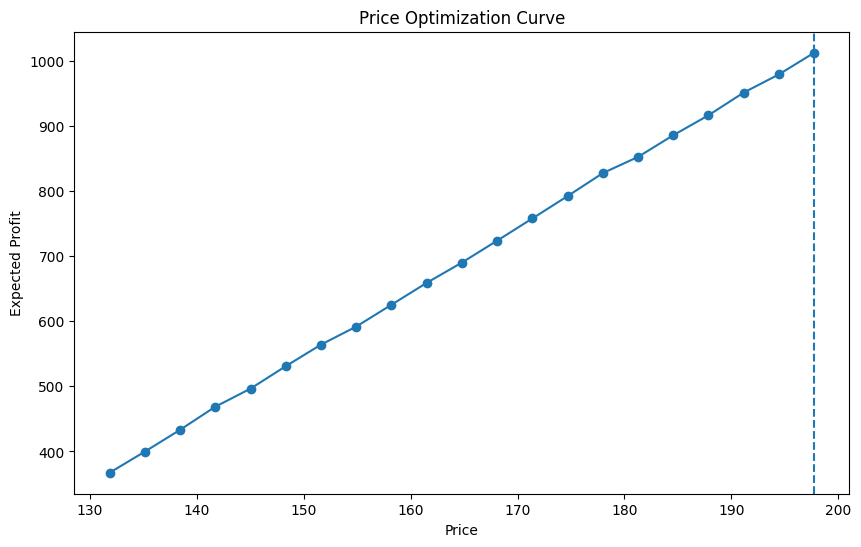

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.plot(
    pricing_results["candidate_price"],
    pricing_results["expected_profit"],
    marker="o"
)

plt.axvline(
    best_price["candidate_price"],
    linestyle="--"
)

plt.xlabel("Price")

plt.ylabel("Expected Profit")

plt.title(
    "Price Optimization Curve"
)

plt.show()